# Семинар 2. Исследование методов линейной регрессии

#### Критерий оценивания:
#### Пункт 14: максимум 0,5 балла
#### Пункт 15: максимум 0,5 балла

#### Итого за работу: максимум 1 балл
#### P.S. пункты 14 и 15 без пунктов 1-13 не засчитываются, ответы на вопросы из ИИ не засчитываются

1. Загрузите датасет и выведите на экран первые несколько строк

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('auto_dataset.csv')
print('Размер датасета:', data.shape)
data.head()

Размер датасета: (1000, 10)


,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


2. Разбейте выборку на признаки и ответы. Закодируйте категориальные признаки.

In [8]:
target = 'price'
cat_cols = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']

# One-Hot Encoding. drop_first=True убирает по одной категории из каждого признака,
# чтобы не было линейной зависимости между столбцами.
data_enc = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print('Размер после кодирования:', data_enc.shape)
data_enc.head()

Размер после кодирования: (1000, 205)


,powerPS,kilometer,autoAgeMonths,price,brand_audi,brand_bmw,brand_chevrolet,brand_chrysler,brand_citroen,brand_dacia,...,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,gearbox_manuell,fuelType_benzin,fuelType_diesel,fuelType_hybrid,fuelType_lpg,notRepairedDamage_nein
0,75,150000,177,1500,False,False,False,False,False,False,...,True,False,False,False,True,True,False,False,False,True
1,69,90000,93,3600,False,False,False,False,False,False,...,True,False,False,False,True,False,True,False,False,True
2,102,150000,246,650,False,True,False,False,False,False,...,False,False,True,False,True,True,False,False,False,False
3,109,150000,140,2200,False,False,False,False,False,False,...,False,False,False,False,True,True,False,False,False,True
4,105,150000,136,2000,False,False,False,False,False,False,...,False,False,True,False,True,True,False,False,False,True


3. Разбейте датасет на train val test в отношении 8:1:1

In [9]:
n = len(data_enc)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train = data_enc.iloc[:n_train].copy()
val   = data_enc.iloc[n_train:n_train + n_val].copy()
test  = data_enc.iloc[n_train + n_val:].copy()

print('Размеры:')
print(f'  train: {train.shape}')
print(f'  val:   {val.shape}')
print(f'  test:  {test.shape}')

Размеры:
  train: (800, 205)
  val:   (100, 205)
  test:  (100, 205)


In [11]:
feature_cols = [c for c in data_enc.columns if c != target]

X_train = train[feature_cols].values.astype(float)
y_train = train[target].values.astype(float)
X_val   = val[feature_cols].values.astype(float)
y_val   = val[target].values.astype(float)
X_test  = test[feature_cols].values.astype(float)
y_test  = test[target].values.astype(float)

# Стандартизация по статистикам train
mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0

X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma
X_test  = (X_test  - mu) / sigma

# Столбец единиц для свободного члена w0
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_val   = np.hstack([np.ones((X_val.shape[0], 1)),   X_val])
X_test  = np.hstack([np.ones((X_test.shape[0], 1)),  X_test])

print('Размеры:')
print(f'  X_train: {X_train.shape}')
print(f'  X_val:   {X_val.shape}')
print(f'  X_test:  {X_test.shape}')

Размеры:
  X_train: (800, 205)
  X_val:   (100, 205)
  X_test:  (100, 205)


In [12]:
class LinearRegressor:
    """
    Линейная регрессия, обучаемая одним из 5 методов:
    'vanilla', 'sgd', 'sag', 'momentum', 'adam'.

    Расписание длины шага:
      schedule='constant' -> eta_k = lam (постоянный шаг)
      schedule='timedecay' -> eta_k = lam * (s0/(s0+k))^p
    """

    def __init__(self, method='vanilla', schedule='constant', lam=0.01,
                 max_iter=5000, tol=1e-8, batch_size=1,
                 s0=1.0, p=0.5, alpha=0.9,
                 beta1=0.9, beta2=0.999, eps=1e-8, seed=42):
        self.method = method
        self.schedule = schedule
        self.lam = lam
        self.max_iter = max_iter
        self.tol = tol
        self.batch_size = batch_size
        self.s0 = s0
        self.p = p
        self.alpha = alpha
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.seed = seed

        self.w = None
        self.history_mse = []
        self.n_iter_ = 0

    # ---------- вспомогательные ----------

    def _lr(self, k):
        if self.schedule == 'constant':
            return self.lam
        elif self.schedule == 'timedecay':
            return self.lam * (self.s0 / (self.s0 + k)) ** self.p
        else:
            raise ValueError(f'Unknown schedule: {self.schedule}')

    def _mse(self, X, y):
        return float(np.mean((X @ self.w - y) ** 2))

    def _grad_full(self, X, y):
        n = X.shape[0]
        return (2.0 / n) * X.T @ (X @ self.w - y)

    # ---------- публичные ----------

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.history_mse = []
        self.n_iter_ = 0
        rng = np.random.default_rng(self.seed)

        if   self.method == 'vanilla':  self._fit_vanilla(X, y)
        elif self.method == 'sgd':      self._fit_sgd(X, y, rng)
        elif self.method == 'sag':      self._fit_sag(X, y, rng)
        elif self.method == 'momentum': self._fit_momentum(X, y)
        elif self.method == 'adam':     self._fit_adam(X, y)
        else:
            raise ValueError(f'Unknown method: {self.method}')
        return self

    def predict(self, X):
        return X @ self.w

    # ---------- реализации методов ----------

    def _fit_vanilla(self, X, y):
        for k in range(self.max_iter):
            self.history_mse.append(self._mse(X, y))
            grad = self._grad_full(X, y)
            if np.linalg.norm(grad) < self.tol:
                break
            eta = self._lr(k)
            self.w = self.w - eta * grad
            self.n_iter_ = k + 1
        self.history_mse.append(self._mse(X, y))

    def _fit_sgd(self, X, y, rng):
        n = X.shape[0]
        for k in range(self.max_iter):
            self.history_mse.append(self._mse(X, y))
            idx = rng.integers(0, n, size=self.batch_size)
            Xb, yb = X[idx], y[idx]
            grad = (2.0 / self.batch_size) * Xb.T @ (Xb @ self.w - yb)
            eta = self._lr(k)
            self.w = self.w - eta * grad
            self.n_iter_ = k + 1
        self.history_mse.append(self._mse(X, y))

    def _fit_sag(self, X, y, rng):
        n, d = X.shape
        g_store = np.zeros((n, d))
        for i in range(n):
            g_store[i] = 2.0 * (X[i] @ self.w - y[i]) * X[i]
        g_bar = g_store.mean(axis=0)

        for k in range(self.max_iter):
            self.history_mse.append(self._mse(X, y))
            j = int(rng.integers(0, n))
            g_new = 2.0 * (X[j] @ self.w - y[j]) * X[j]
            g_bar = g_bar + (g_new - g_store[j]) / n
            g_store[j] = g_new
            eta = self._lr(k)
            self.w = self.w - eta * g_bar
            self.n_iter_ = k + 1
        self.history_mse.append(self._mse(X, y))

    def _fit_momentum(self, X, y):
        h = np.zeros_like(self.w)
        for k in range(self.max_iter):
            self.history_mse.append(self._mse(X, y))
            grad = self._grad_full(X, y)
            if np.linalg.norm(grad) < self.tol:
                break
            eta = self._lr(k)
            h = self.alpha * h + eta * grad
            self.w = self.w - h
            self.n_iter_ = k + 1
        self.history_mse.append(self._mse(X, y))

    def _fit_adam(self, X, y):
        m = np.zeros_like(self.w)
        v = np.zeros_like(self.w)
        for k in range(self.max_iter):
            self.history_mse.append(self._mse(X, y))
            g = self._grad_full(X, y)
            if np.linalg.norm(g) < self.tol:
                break

            m = self.beta1 * m + (1 - self.beta1) * g
            v = self.beta2 * v + (1 - self.beta2) * g * g

            m_hat = m / (1 - self.beta1 ** (k + 1))
            v_hat = v / (1 - self.beta2 ** (k + 1))

            eta = self._lr(k)
            self.w = self.w - eta * m_hat / (np.sqrt(v_hat) + self.eps)
            self.n_iter_ = k + 1
        self.history_mse.append(self._mse(X, y))

In [13]:
def mse_loss(X, y, w):
    return float(np.mean((X @ w - y) ** 2))

def r2_score(X, y, w):
    y_pred = X @ w
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1.0 - ss_res / ss_tot


def run_experiment(method, schedule, lambda_grid,
                   X_train, y_train, X_val, y_val, X_test, y_test,
                   max_iter=3000, batch_size=1, plot=True):
    """
    Полный цикл для одного метода и одного расписания.
    Перебирает lambda_grid, находит лучший шаг по Loss_val,
    обучает финальную модель и считает метрики на тесте.
    """
    rows = []

    for lam in lambda_grid:
        model = LinearRegressor(method=method, schedule=schedule,
                                lam=lam, max_iter=max_iter,
                                batch_size=batch_size)
        model.fit(X_train, y_train)

        rows.append({
            'lam':        lam,
            'loss_train': mse_loss(X_train, y_train, model.w),
            'loss_val':   mse_loss(X_val,   y_val,   model.w),
            'r2_train':   r2_score(X_train, y_train, model.w),
        })

    df = pd.DataFrame(rows)
    best = df.loc[df['loss_val'].idxmin()]
    best_lam = best['lam']

    model_best = LinearRegressor(method=method, schedule=schedule,
                                 lam=best_lam, max_iter=max_iter,
                                 batch_size=batch_size)
    model_best.fit(X_train, y_train)

    result = {
        'method':     method,
        'schedule':   schedule,
        'best_lam':   best_lam,
        'loss_train': best['loss_train'],
        'loss_val':   best['loss_val'],
        'loss_test':  mse_loss(X_test, y_test, model_best.w),
        'r2_train':   best['r2_train'],
        'r2_test':    r2_score(X_test, y_test, model_best.w),
        'n_iter':     model_best.n_iter_,
        'model':      model_best,
        'df_grid':    df,
    }

    print(f'  {method} / {schedule}: best λ = {best_lam:.0e}, '
          f'R²_val = {r2_score(X_val, y_val, model_best.w):.4f}, '
          f'R²_test = {result["r2_test"]:.4f}, '
          f'итераций = {result["n_iter"]}')

    if plot:
        plt.figure(figsize=(9, 4))
        plt.plot(model_best.history_mse)
        plt.yscale('log')
        plt.xlabel('Итерация k')
        plt.ylabel('MSE на train (log)')
        plt.title(f'{method} / {schedule} (λ* = {best_lam:.0e})')
        plt.grid(True, which='both')
        plt.show()

    return result

4. Исследуйте VGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

/Users/alexandratikhonova/практикум ML/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/51/35v_mkhn1sg_jnrt8d__30_00000gn/T/ipykernel_11939/1135727296.py:44: RuntimeWarning: overflow encountered in square
  return float(np.mean((X @ self.w - y) ** 2))


  vanilla / constant: best λ = 1e-03, R²_val = 0.5853, R²_test = 0.7498, итераций = 3000


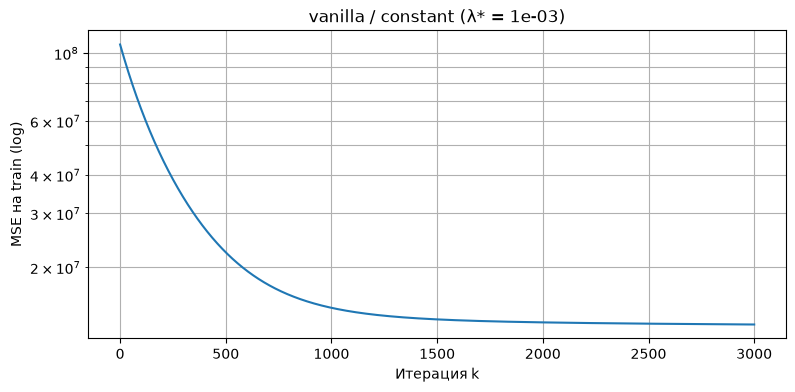

In [14]:
lambda_grid = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]

res_vgd_const = run_experiment(
    method='vanilla', schedule='constant',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

5. Исследуйте VGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите VGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте VGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте VGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  vanilla / timedecay: best λ = 1e-02, R²_val = 0.5799, R²_test = 0.7525, итераций = 3000


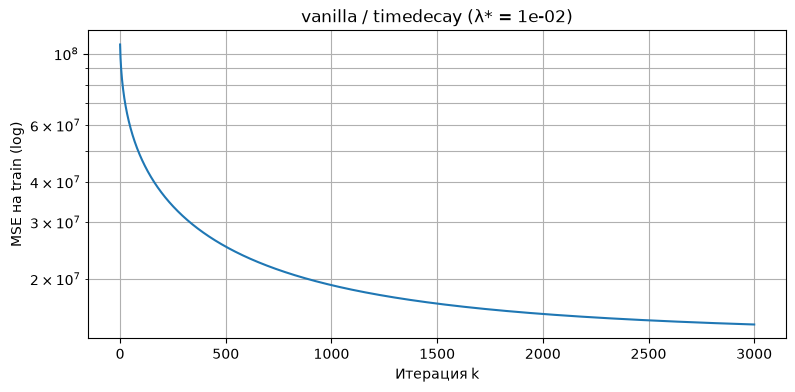

In [15]:
res_vgd_td = run_experiment(
    method='vanilla', schedule='timedecay',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

6. Исследуйте SGD с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  sgd / constant: best λ = 1e-04, R²_val = 0.3119, R²_test = 0.4463, итераций = 3000


/var/folders/51/35v_mkhn1sg_jnrt8d__30_00000gn/T/ipykernel_11939/1135727296.py:44: RuntimeWarning: overflow encountered in square
  return float(np.mean((X @ self.w - y) ** 2))
/var/folders/51/35v_mkhn1sg_jnrt8d__30_00000gn/T/ipykernel_11939/1135727296.py:92: RuntimeWarning: invalid value encountered in subtract
  self.w = self.w - eta * grad


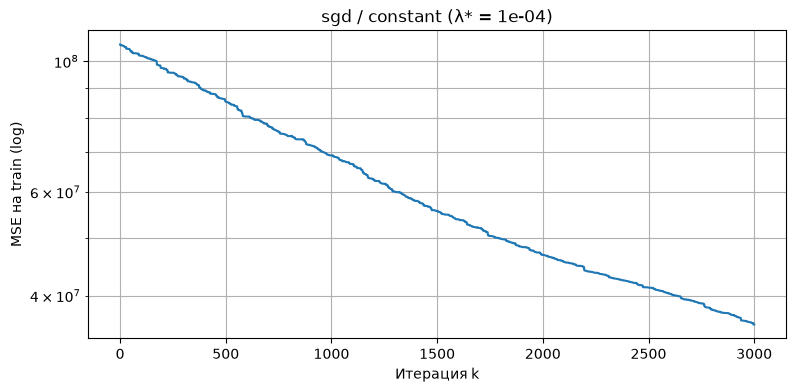

In [16]:
res_sgd_const = run_experiment(
    method='sgd', schedule='constant',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

7. Исследуйте SGD с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SGD на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SGD на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SGD c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  sgd / timedecay: best λ = 1e-02, R²_val = 0.6071, R²_test = 0.7473, итераций = 3000


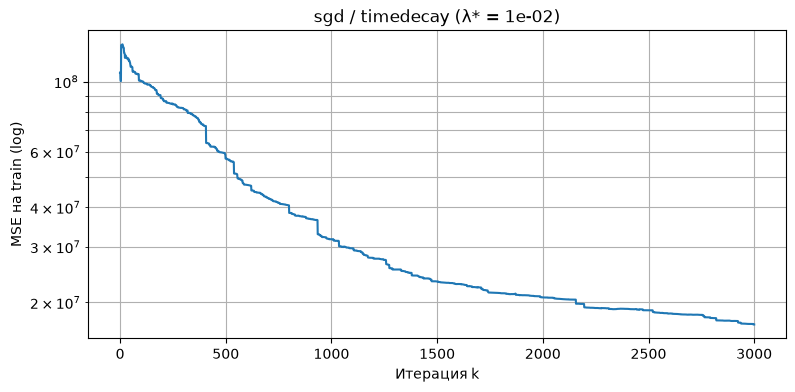

In [17]:
res_sgd_td = run_experiment(
    method='sgd', schedule='timedecay',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

8. Исследуйте SAG с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  sag / constant: best λ = 1e-04, R²_val = 0.3647, R²_test = 0.5685, итераций = 3000


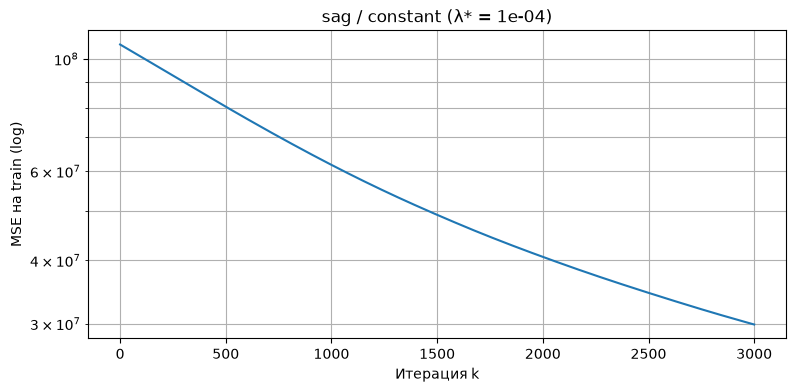

In [18]:
res_sag_const = run_experiment(
    method='sag', schedule='constant',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

9. Исследуйте SAG с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите SAG на train
* найдите и запомните R^2_train и Loss_train
* протестируйте SAG на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте SAG c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  sag / timedecay: best λ = 1e-02, R²_val = 0.4139, R²_test = 0.6602, итераций = 3000


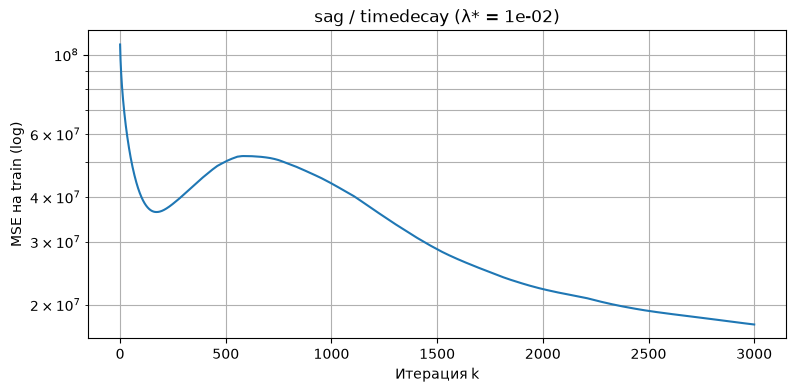

In [19]:
res_sag_td = run_experiment(
    method='sag', schedule='timedecay',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

10. Исследуйте Momentum с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

/var/folders/51/35v_mkhn1sg_jnrt8d__30_00000gn/T/ipykernel_11939/1135727296.py:44: RuntimeWarning: overflow encountered in square
  return float(np.mean((X @ self.w - y) ** 2))


  momentum / constant: best λ = 1e-04, R²_val = 0.5853, R²_test = 0.7497, итераций = 3000


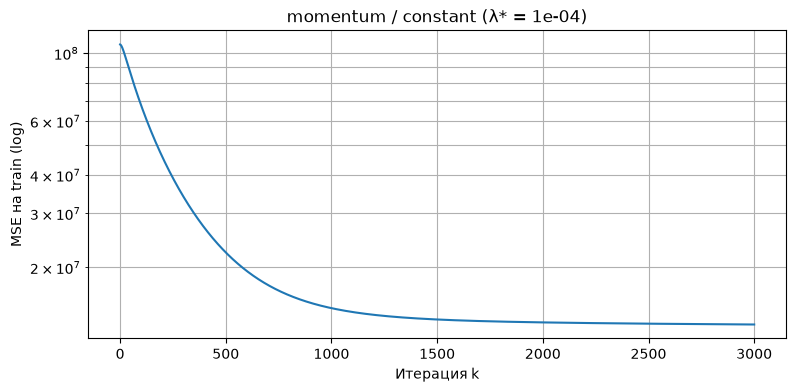

In [20]:
res_mom_const = run_experiment(
    method='momentum', schedule='constant',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

11. Исследуйте Momentum с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Momentum на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Momentum на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Momentum c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  momentum / timedecay: best λ = 1e-03, R²_val = 0.5804, R²_test = 0.7528, итераций = 3000


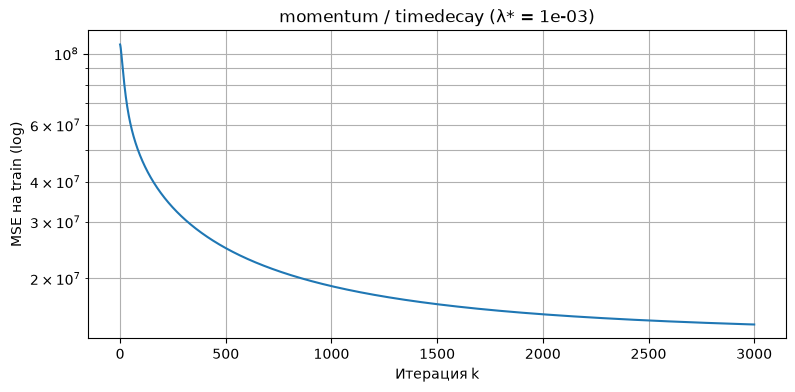

In [21]:
res_mom_td = run_experiment(
    method='momentum', schedule='timedecay',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

12. Исследуйте Adam с постоянным шагом n:

переберите n в логарифмической сетке от 10^-5 до 1

для каждого n:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший n по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c лучшим n на test, запомните Loss_test, R^2_test, число итераций на test.

  adam / constant: best λ = 1e+00, R²_val = 0.2400, R²_test = 0.5196, итераций = 3000


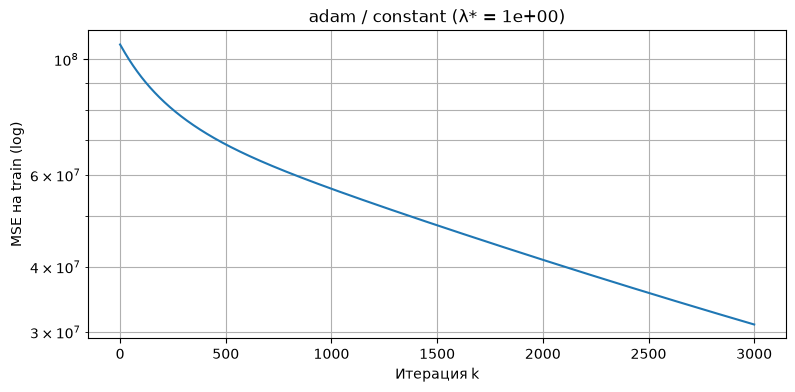

In [22]:
res_adam_const = run_experiment(
    method='adam', schedule='constant',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

13. Исследуйте Adam с переменным шагом n(lyamda) по формуле TimeDecayLR (из лекции):

переберите lyamda в логарифмической сетке от 10^-5 до 1

для каждого lyamda:

* обучите Adam на train
* найдите и запомните R^2_train и Loss_train
* протестируйте Adam на val, запомните Loss_val

найдите наилучший lyamda по минимальному Loss_val, запомните его Loss_train, R^2_train, Loss_val;

протестируйте Adam c n(best_lyamda) на test, запомните Loss_test, R^2_test, число итераций на test.

  adam / timedecay: best λ = 1e+00, R²_val = -0.6210, R²_test = -0.5686, итераций = 3000


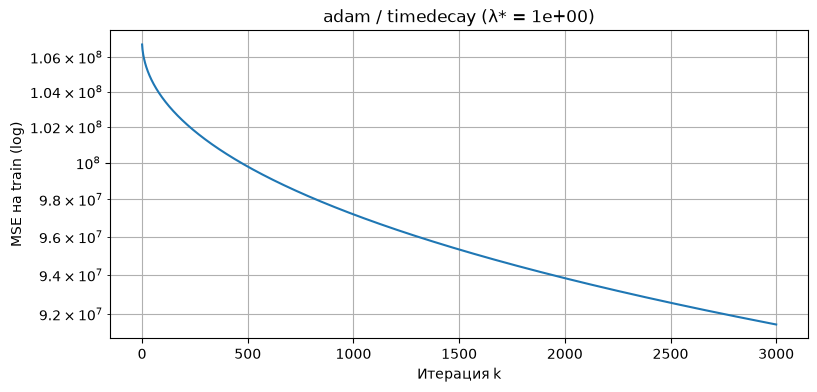

In [23]:
res_adam_td = run_experiment(
    method='adam', schedule='timedecay',
    lambda_grid=lambda_grid,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    X_test=X_test,   y_test=y_test,
    max_iter=3000,
)

14. Постройте итоговую сравнительную таблицу со следующими столбцами:

1) название метода

2) значение лучшего шага (если n) или функция лучшего шага (если n(lyamda))

3) Loss_train

4) Loss_test

5) R^2 train

6) R^2 test

7) число итераций на test

In [27]:
all_results = [
    res_vgd_const, res_vgd_td,
    res_sgd_const, res_sgd_td,
    res_sag_const, res_sag_td,
    res_mom_const, res_mom_td,
    res_adam_const, res_adam_td,
]

method_names = {
    'vanilla':  'VanillaGradientDescent',
    'sgd':      'StochasticGradientDescent',
    'sag':      'SAGDescent',
    'momentum': 'MomentumDescent',
    'adam':     'Adam',
}

def fmt_num(x):
    """Форматирует число без экспоненты: 0.001, 0.0001, 1 (не 1e-03)."""
    s = f"{x:.10f}".rstrip('0').rstrip('.')
    return s if s else '0'

def step_label(r):
    if r['schedule'] == 'constant':
        return f"n = {fmt_num(r['best_lam'])}"
    else:
        return f"n(λ) = {fmt_num(r['best_lam'])} / √(1+k)"

rows = []
for r in all_results:
    rows.append({
        'Метод':        method_names[r['method']],
        'Расписание':   'постоянный' if r['schedule'] == 'constant' else 'TimeDecay',
        'Лучший шаг':   step_label(r),
        'Loss_train':   r['loss_train'],
        'Loss_test':    r['loss_test'],
        'R²_train':     r['r2_train'],
        'R²_test':      r['r2_test'],
        'Итераций':     r['n_iter'],
    })

summary = pd.DataFrame(rows)
summary.round(4)

summary['Loss_train'] = summary['Loss_train'].round(2)
summary['Loss_test']  = summary['Loss_test'].round(2)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
summary

,Метод,Расписание,Лучший шаг,Loss_train,Loss_test,R²_train,R²_test,Итераций
0,VanillaGradientDescent,постоянный,n = 0.001,"13,033,915.67","18,634,622.38",0.78,0.75,3000
1,VanillaGradientDescent,TimeDecay,n(λ) = 0.01 / √(1+k),"14,414,897.42","18,429,662.42",0.76,0.75,3000
2,StochasticGradientDescent,постоянный,n = 0.0001,"35,723,500.89","41,236,661.48",0.39,0.45,3000
3,StochasticGradientDescent,TimeDecay,n(λ) = 0.01 / √(1+k),"17,025,368.17","18,816,791.55",0.71,0.75,3000
4,SAGDescent,постоянный,n = 0.0001,"29,877,256.73","32,137,881.53",0.49,0.57,3000
5,SAGDescent,TimeDecay,n(λ) = 0.01 / √(1+k),"17,584,191.17","25,307,174.28",0.70,0.66,3000
6,MomentumDescent,постоянный,n = 0.0001,"13,034,119.48","18,638,461.58",0.78,0.75,3000
7,MomentumDescent,TimeDecay,n(λ) = 0.001 / √(1+k),"14,378,596.01","18,411,034.40",0.76,0.75,3000
8,Adam,постоянный,n = 1,"31,007,285.70","35,779,182.79",0.47,0.52,3000
9,Adam,TimeDecay,n(λ) = 1 / √(1+k),"91,466,077.11","116,824,069.60",-0.55,-0.57,3000


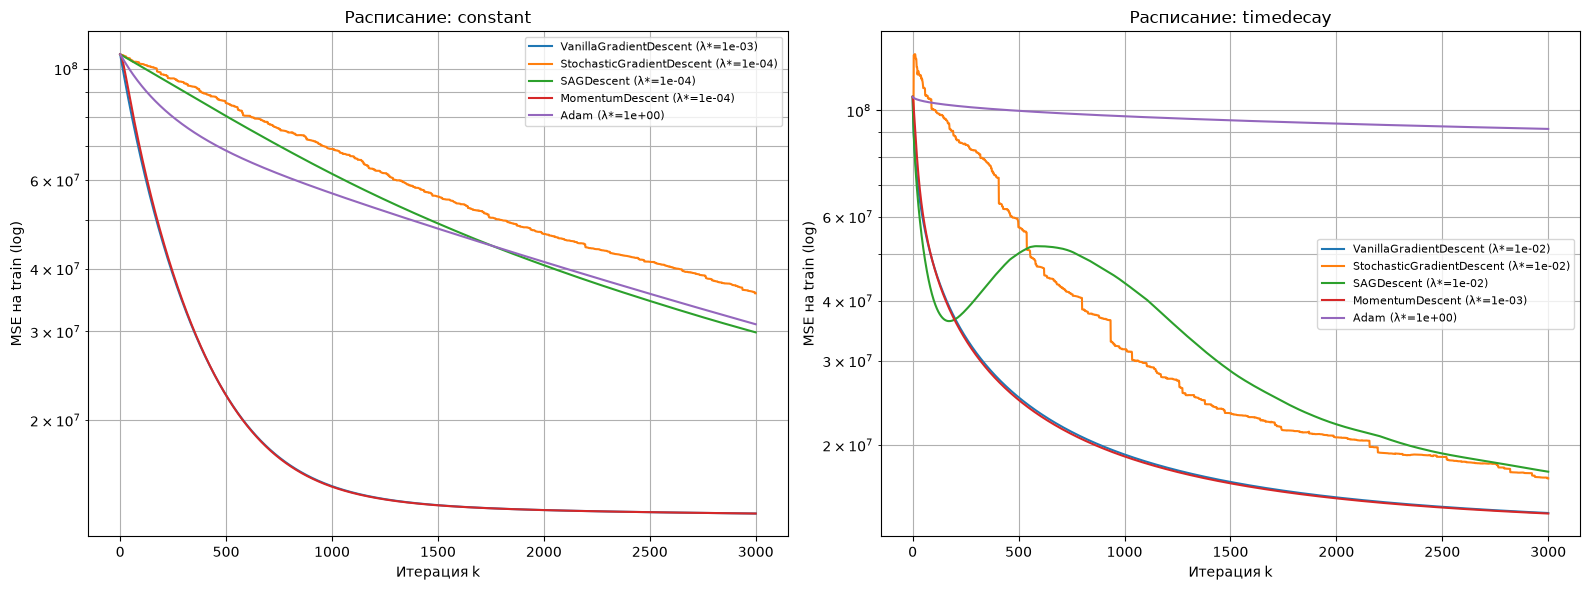

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, sched in zip(axes, ['constant', 'timedecay']):
    for r in all_results:
        if r['schedule'] != sched:
            continue
        ax.plot(r['model'].history_mse,
                label=f"{method_names[r['method']]} (λ*={r['best_lam']:.0e})")
    ax.set_yscale('log')
    ax.set_xlabel('Итерация k')
    ax.set_ylabel('MSE на train (log)')
    ax.set_title(f'Расписание: {sched}')
    ax.grid(True, which='both')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

15. Сделайте вывод о том, какой метод и шаг линейной регрессии самый лучший для данной выборки и ответьте на вопросы:

1) почему именно этот метод и этот шаг самый лучший (по каким данным из таблицы вы сделали такой вывод)

2) расскажите простыми словами суть R^2_train и R^2_test?

3) как R^2_train и R^2_test помогают сравнивать методы? почему оба эти значения надо вычислять для данного выбора?

1. По таблице лучший результат у Momentum c TimeDecay и лямбдой 10^(-3). У него самый низкий Loss_test b самый высокий R^2_test из всех десяти строк.
2. R^2 - это доля разброса цены, которую объяснила модель. Если R^2=1, то модель угадывает все цены. Если 0, то она даже не лучше чем выдавать всегда среднюю цену. Если меньше ноля, то модель хуже среднего, то есть вообще бесполезная. R^2_train считается на обучающей выборке, а R^2_test на тестовой. У нас в таблице получился лучший результат R^2_train=R^2_test=0.75. То есть модель объясняет около 75% разброса цен.
3. Их нужно смотреть вместе, потому что по отдельности они мало полезны. train если высокий, значит модель хорошо описывает обучающую выборку, но это не означает что она будет работать на новых данных. Если train высокий, а test ниже - переобучение, если оба низкие - недообучение, если оба близкие и высокие - все ок. А если мы будем считать только test, то можем не понять например что это чистая случайность, а не хорошо обученная модель.